# Техники подбора гиперпараметров



## Проверка связи

**Поставьте в чат:**<br>
\+ — если меня видно и слышно<br>
**–** — если нет

**Если у вас нет звука:**

* убедитесь, что на вашем устройстве и в колонках включён звук

* обновите страницу вебинара или закройте её и переподключитесь

* откройте вебинар в другом браузере

* перезагрузите ваше устройство и подключитесь снова

## О преподавателе

**[Олег Булыгин](https://olegtalks.ru/)**

👨‍💻 **Опыт в образовании**
* В IT-образовании с 2017 года. Провёл более 1 500 лекций и вебинаров, обучил тысячи студентов, многие из которых сейчас работают в ведущих IT-компаниях
*  Создаю авторские курсы, консультирую крупные компании по вопросам data science, участвую в разработке образовательных программ для университетов и онлайн-школ

🎯 Стремлюсь сделать обучение качественным и честным для всех, кто хочет развиваться в IT-сфере

📱 Делюсь полезными материалами по Python:
- [Telegram](https://t.me/pythontalk_ru)
- [Дзен](https://dzen.ru/pythontalk)
</div>

Автор: **[Булыгин Олег](https://olegtalks.ru/)**
* [Мой канал в ТГ по Python](https://t.me/pythontalk_ru)

## Правила участия

1. Продолжительность вебинара — 1 час 30 минут. Через 45 минут сделаем 5-минутный перерыв
2. Запустите Jupyter Notebook / Google Colab / IDE для выполнения практических заданий вебинара. Во время демонстрации работы можете повторять за преподавателем: это помогает лучше понять материал
3. Создайте копию этого блокнота и фиксируйте в нём вопросы и важную информацию во время занятия
4. Вы можете писать вопросы в чате во время вебинара или задавать их вслух в блоке «Ваши вопросы»
5. Запись вебинара будет доступна в личном кабинете

## Цели занятия

* Показать на конкретном датасете, как изменение гиперпараметров (например, max_depth, min_samples_leaf) влияет на переобучение, недообучение и качество модели, оцениваемое через кросс‑валидацию и метрику recall

* Научить использовать базовые инструменты автоматического подбора гиперпараметров в sklearn: GridSearchCV, RandomizedSearchCV и методы последовательного отсева (HalvingSearchCV / HalvingRandomSearchCV), анализировать cv_results_ и интерпретировать найденные комбинации

* Сформировать представление об итеративной стратегии оптимизации гиперпараметров (широкий поиск → сужение диапазонов → донастройка) и связать её с практическими ограничениями по времени и вычислительным ресурсам

* Познакомить слушателей с подходами байесовской оптимизации гиперпараметров на примере библиотеки Hyperopt и алгоритма TPE, показать связь между формулировкой целевой функции и критериями улучшения качества модели

## План вебинара
1. Что такое гиперпараметры
2. Инструменты автоматического подбора гиперпараметров
3. HalvingSearchCV

## Что такое гиперпараметры и зачем их оптимизировать?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn import metrics
import time
from scipy.stats import randint

In [ ]:
# Загрузка данных
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target) # 0 = malignant, 1 = benign

# Оригинально: 0=malignant, 1=benign. Хотим: 1=malignant, 0=benign.
y = y.replace({0: 1, 1: 0})

# Разделение данных (только для демонстрации, ОГП будем делать на CV)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в y_train:\n{y_train.value_counts(normalize=True)}")

Размер обучающей выборки: (426, 30)
Размер тестовой выборки: (143, 30)
Распределение классов в y_train:
0    0.626761
1    0.373239
Name: proportion, dtype: float64


Давайте вспомним на примере `DecisionTreeClassifier`:

*   **Параметры:** Структура дерева (какие признаки и пороги выбраны для ветвления на каждом узле). Эти параметры *изучаются* из данных в процессе `fit()`.
*   **Гиперпараметры:** Характеристики, которые мы задаем *до* обучения. Например:
    *   `max_depth`: максимальная глубина дерева.
    *   `min_samples_leaf`: минимальное число объектов в листе.
    *   `criterion`: критерий для оценки качества разбиения ('gini' или 'entropy').
    *   `min_samples_split`: минимальное число объектов для разделения узла.
    *   и другие...

**Ключевая идея:** Разные значения гиперпараметров приводят к моделям с разной сложностью и, как следствие, разным качеством на новых данных. Неправильный выбор может привести к:
*   **Недообучению (Underfitting):** Слишком простая модель (например, `max_depth=1`) плохо улавливает закономерности.
*   **Переобучению (Overfitting):** Слишком сложная модель (например, `max_depth=None`) "запоминает" обучающие данные, но плохо обобщает на новые.

**Пример влияния `max_depth`:**

Давайте загрузим знакомый датасет и посмотрим, как меняется качество дерева решений при изменении только одного гиперпараметра `max_depth`.

In [ ]:
# Оценим качество дерева с разной глубиной на кросс-валидации
depths = range(1, 21) # Протестируем глубины от 1 до 20
cv_scores_mean = []
cv_scores_std = []

# StratifiedKFold важен для сохранения баланса классов в фолдах
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    # Используем cross_val_score для оценки на CV
    scores = cross_val_score(tree, X_train, y_train, cv=skf, scoring='recall', n_jobs=-1)
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

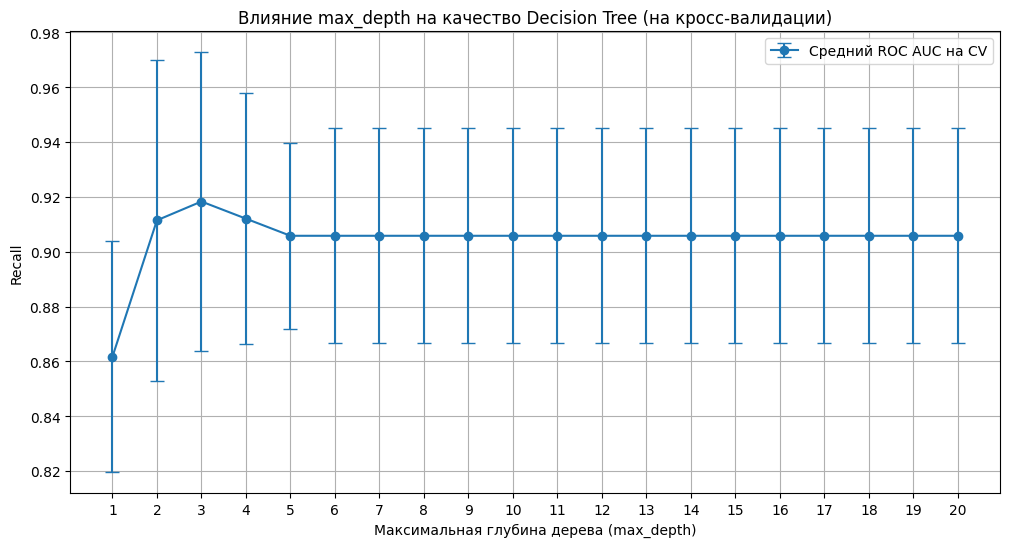

Оптимальная глубина (по среднему recall на CV): 3
Лучший средний recall: 0.9183 +/- 0.0544


In [ ]:
# Визуализация результатов
plt.figure(figsize=(12, 6))
plt.errorbar(depths, cv_scores_mean, yerr=cv_scores_std, marker='o', capsize=5, label='Средний ROC AUC на CV')
plt.xlabel('Максимальная глубина дерева (max_depth)')
plt.ylabel('Recall')
plt.title('Влияние max_depth на качество Decision Tree (на кросс-валидации)')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

best_depth_idx = np.argmax(cv_scores_mean)
print(f"Оптимальная глубина (по среднему recall на CV): {depths[best_depth_idx]}")
print(f"Лучший средний recall: {cv_scores_mean[best_depth_idx]:.4f} +/- {cv_scores_std[best_depth_idx]:.4f}")

**Вывод:** График наглядно показывает, что существует оптимальное значение `max_depth`. Слишком маленькая глубина ведет к недообучению, слишком большая — к переобучению (качество на CV начинает падать или выходит на плато).

**Но что если нужно подобрать не один, а 2, 3, 5 гиперпараметров?** (`max_depth`, `min_samples_leaf`, `min_samples_split`, `criterion`...). Перебирать все комбинации вручную становится нереально.

## Инструменты автоматического подбора гиперпараметров

Зачем они нужны?

*   **Много гиперпараметров:** У современных моделей их могут быть десятки.
*   **Взаимодействия:** Оптимальное значение одного ГП может зависеть от значений других.
*   **Время:** Ручной перебор и оценка на CV занимают очень много времени.
*   **Систематичность:** Автоматические методы гарантируют (или пытаются гарантировать) систематический перебор пространства поиска.

При этом инструменты автоматического подбора гиперпараметров **внутри себя** используют кросс-валидацию для оценки каждой проверяемой комбинации гиперпараметров.

### GridSearchCV (поиск по сетке)

Самый простой и понятный метод автоматического подбора гиперпараметров — это **поиск по сетке (Grid Search)**.

**В чем его суть?**
1.  Мы заранее определяем **сетку** — набор конкретных значений для каждого гиперпараметра, который хотите оптимизировать.
2.  `GridSearchCV` **полностью перебирает все возможные комбинации** этих значений.
3.  Для каждой комбинации он обучает модель и оценивает её качество с помощью кросс-валидации (используя указанную нами `scoring` метрику и `cv` стратегию).
4.  В конце он выбирает комбинацию, которая показала наилучший средний результат на кросс-валидации.

Представьте, что мы подбираем `max_depth` и `min_samples_leaf`.
*   `max_depth`: [3, 5, 7]
*   `min_samples_leaf`: [5, 10, 15]

`GridSearchCV` проверит все 3 * 3 = 9 комбинаций: (3, 5), (3, 10), (3, 15), (5, 5), (5, 10), (5, 15), (7, 5), (7, 10), (7, 15).

Используем GridSearchCV для подбора max_depth, min_samples_leaf и min_samples_split для нашего DecisionTreeClassifier.

In [ ]:
estimator = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Задаем сетку параметров (param_grid) - словарь
# Ключи - названия гиперпараметров (строки)
# Значения - списки значений для перебора
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, 12],             # 6 значений
    'min_samples_leaf': [2, 4, 6, 8, 10],          # 5 значений
    'min_samples_split': [4, 6, 8, 10]            # 4 значения

}
# Общее число комбинаций: 6 * 5 * 4 = 120 комбинаций

In [ ]:
from sklearn.model_selection import GridSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Создаем объект GridSearchCV
grid_search = GridSearchCV(
    estimator=estimator,      # Модель для оптимизации
    param_grid=param_grid,    # Сетка гиперпараметров
    scoring='recall',         # Метрика для оценки (хотим максимизировать Recall)
    cv=skf,                   # Стратегия кросс-валидации
    n_jobs=-1,                # Использовать все доступные ядра CPU для параллелизации
    verbose=1,                 # Выводить информацию о процессе
    return_train_score=True
)

# Запускаем поиск (обучение)
print("Запуск GridSearchCV...")
start_time_grid = time.time()
grid_search.fit(X_train, y_train)
end_time_grid = time.time()
print(f"GridSearchCV завершен за {end_time_grid - start_time_grid:.2f} секунд.")



Запуск GridSearchCV...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
GridSearchCV завершен за 17.38 секунд.


In [ ]:
# Анализ результатов
print("\n--- Результаты GridSearchCV ---")
print(f"Наилучшее значение Recall на кросс-валидации: {grid_search.best_score_:.4f}")
print(f"Наилучшая комбинация гиперпараметров: {grid_search.best_params_}")


--- Результаты GridSearchCV ---
Наилучшее значение Recall на кросс-валидации: 0.9246
Наилучшая комбинация гиперпараметров: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 4}


In [ ]:
# Модель с лучшими параметрами, обученная на ВСЕЙ обучающей выборке (X_train, y_train)
best_model_grid = grid_search.best_estimator_
print(f"\nЛучшая модель:\n{best_model_grid}")


Лучшая модель:
DecisionTreeClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=2,
                       min_samples_split=4, random_state=42)


In [ ]:
# Оценка лучшей модели на тестовой выборке (делаем один раз в конце!)
y_test_pred_grid = best_model_grid.predict(X_test)
print(f"\nRecall лучшей модели на тестовой выборке: {metrics.recall_score(y_test, y_test_pred_grid):.4f}")


Recall лучшей модели на тестовой выборке: 0.9057


**Изучение `cv_results_`**

Атрибут `cv_results_` содержит подробную информацию о **каждой** проверенной комбинации гиперпараметров. Это очень полезно для анализа! Его удобно смотреть в виде `pandas.DataFrame`.

In [ ]:
# Преобразуем результаты в DataFrame
results_grid = pd.DataFrame(grid_search.cv_results_)

# Отсортируем по убыванию среднего значения метрики на CV
results_grid = results_grid.sort_values(by='mean_test_score', ascending=False)

print("\n--- Детальные результаты GridSearchCV (cv_results_) ---")
display(results_grid[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])



--- Детальные результаты GridSearchCV (cv_results_) ---


,params,mean_test_score,std_test_score,rank_test_score
23,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.924597,0.050682,1
22,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.924597,0.050682,1
21,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.924597,0.050682,1
20,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.924597,0.050682,1
27,"{'max_depth': 4, 'min_samples_leaf': 4, 'min_s...",0.918347,0.042219,5
...,...,...,...,...
95,"{'max_depth': 10, 'min_samples_leaf': 8, 'min_...",0.905040,0.061223,101
115,"{'max_depth': 12, 'min_samples_leaf': 8, 'min_...",0.905040,0.061223,101
114,"{'max_depth': 12, 'min_samples_leaf': 8, 'min_...",0.905040,0.061223,101
113,"{'max_depth': 12, 'min_samples_leaf': 8, 'min_...",0.905040,0.061223,101


In [ ]:
# Можно посмотреть, сколько времени заняла каждая комбинация (примерно)
print("\nВремя на каждую комбинацию (примерно):")
display(results_grid[['params', 'mean_fit_time', 'mean_score_time']])


Время на каждую комбинацию (примерно):


,params,mean_fit_time,mean_score_time
23,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.040554,0.018694
22,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.035223,0.016128
21,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.040368,0.019536
20,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.051894,0.027563
27,"{'max_depth': 4, 'min_samples_leaf': 4, 'min_s...",0.023787,0.011670
...,...,...,...
95,"{'max_depth': 10, 'min_samples_leaf': 8, 'min_...",0.013283,0.005690
115,"{'max_depth': 12, 'min_samples_leaf': 8, 'min_...",0.015712,0.007605
114,"{'max_depth': 12, 'min_samples_leaf': 8, 'min_...",0.013087,0.006146
113,"{'max_depth': 12, 'min_samples_leaf': 8, 'min_...",0.012928,0.005767


**Плюсы и мнусы `GridSearchCV`**

**Плюсы:**
*   **Простота:** Легко понять и использовать.
*   **Исчерпывающий (в рамках сетки):** Гарантированно находит лучшую комбинацию *из тех, что задали в сетке*.

**Минусы:**
*   **Вычислительная сложность:** Количество комбинаций растет экспоненциально с добавлением новых гиперпараметров или значений в них. Может быть *очень* долго.
*   **Неэффективность:** Тратит много времени на заведомо плохие области пространства поиска.
*   **Дискретность:** Оптимальное значение может лежать *между* точками  сетки (особенно для непрерывных параметров).

### Случайный поиск (RandomizedSearchCV)

Как мы видели, `GridSearchCV` может быть очень медленным. **Случайный поиск (Random Search)** предлагает более эффективную альтернативу.

**В чём его суть?**
1.  Мы определяем **пространство поиска** для каждого гиперпараметра:
    *   Это могут быть списки значений (как в Grid Search).
    *   Или, что более гибко, **статистические распределения** (например, равномерное, логнормальное).
2.  Задаём **количество итераций (`n_iter`)** — сколько случайных комбинаций гиперпараметров нужно проверить.
3.  `RandomizedSearchCV` случайным образом выбирает `n_iter` комбинаций из заданного пространства.
4.  Для каждой выбранной комбинации он, как и Grid Search, оценивает качество на кросс-валидации.
5.  Выбирает лучшую из **проверенных** `n_iter` комбинаций.

**Почему это часто работает лучше Grid Search?**

Исследование *Bergstra & Bengio (2012)* показало, что для большинства задач не все гиперпараметры одинаково важны. `GridSearchCV` тратит много ресурсов на точную настройку неважных параметров. `RandomizedSearchCV`, пробуя случайные комбинации, с большей вероятностью найдет хорошие значения для **важных** параметров за то же (или меньшее) количество итераций.


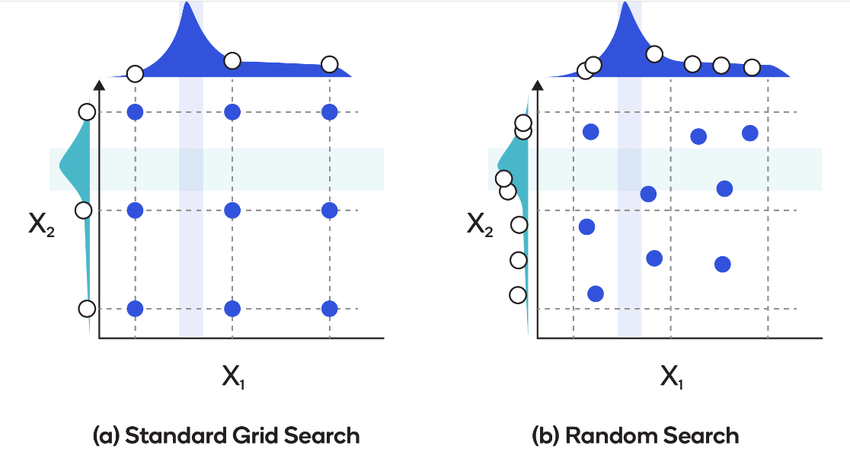

In [ ]:
# Задаем пространство поиска (param_distributions) - словарь
# Ключи - названия ГП
# Значения - списки ИЛИ распределения из scipy.stats
param_distributions = {
    # Для целочисленных параметров можно использовать randint(low, high+1)
    'max_depth': randint(2, 13), # Случайные целые числа от 2 до 12 включительно
    'min_samples_leaf': randint(2, 11), # Случайные целые от 2 до 10
    'min_samples_split': randint(4, 11), # Случайные целые от 4 до 10
}

n_iterations = 50 # Попробуем 50 случайных комбинаций

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_distributions, # Пространство поиска
    n_iter=n_iterations,                # Количество итераций
    scoring='recall',                   # Метрика
    cv=skf,                             # Стратегия CV
    n_jobs=-1,                          # Параллелизация
    verbose=1,                          # Вывод информации
    random_state=42                     # Для воспроизводимости случайного выбора!
)


print(f"\nЗапуск RandomizedSearchCV (n_iter={n_iterations})...")
start_time_random = time.time()
random_search.fit(X_train, y_train)
end_time_random = time.time()
print(f"RandomizedSearchCV завершен за {end_time_random - start_time_random:.2f} секунд.")


Запуск RandomizedSearchCV (n_iter=50)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV завершен за 4.12 секунд.


In [ ]:
print("\n--- Результаты RandomizedSearchCV ---")
print(f"Наилучшее значение Recall на кросс-валидации: {random_search.best_score_:.4f}")
print(f"Наилучшая комбинация гиперпараметров: {random_search.best_params_}")


--- Результаты RandomizedSearchCV ---
Наилучшее значение Recall на кросс-валидации: 0.9246
Наилучшая комбинация гиперпараметров: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [ ]:
# Лучшая модель
best_model_random = random_search.best_estimator_
print(f"\nЛучшая модель:\n{best_model_random}")

# Оценка лучшей модели на тесте
y_test_pred_random = best_model_random.predict(X_test)
print(f"\nRecall лучшей модели на тестовой выборке: {metrics.recall_score(y_test, y_test_pred_random):.4f}")


Лучшая модель:
DecisionTreeClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=2,
                       min_samples_split=10, random_state=42)

Recall лучшей модели на тестовой выборке: 0.8679


In [ ]:
# Сравнение с GridSearch
print("\n--- Сравнение с GridSearchCV ---")
print(f"Время GridSearch: {end_time_grid - start_time_grid:.2f} сек ({len(results_grid)} комбинаций)")
print(f"Время RandomSearch: {end_time_random - start_time_random:.2f} сек ({n_iterations} комбинаций)")
print(f"Лучший Recall GridSearch (на CV): {grid_search.best_score_:.4f}")
print(f"Лучший Recall RandomSearch (на CV): {random_search.best_score_:.4f}")


--- Сравнение с GridSearchCV ---
Время GridSearch: 17.38 сек (120 комбинаций)
Время RandomSearch: 4.12 сек (50 комбинаций)
Лучший Recall GridSearch (на CV): 0.9246
Лучший Recall RandomSearch (на CV): 0.9246


**Изучение `cv_results_`**

Аналогично `GridSearchCV`, можно посмотреть все проверенные комбинации.

In [ ]:
# Преобразуем результаты в DataFrame
results_random = pd.DataFrame(random_search.cv_results_)
results_random = results_random.sort_values(by='mean_test_score', ascending=False)

print("\n--- Детальные результаты RandomizedSearchCV (cv_results_) ---")
display(results_random[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])


--- Детальные результаты RandomizedSearchCV (cv_results_) ---


,params,mean_test_score,std_test_score,rank_test_score
38,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",0.924597,0.050682,1
43,"{'max_depth': 4, 'min_samples_leaf': 2, 'min_s...",0.924597,0.050682,1
11,"{'max_depth': 12, 'min_samples_leaf': 4, 'min_...",0.918347,0.042219,3
10,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",0.918347,0.024709,3
41,"{'max_depth': 12, 'min_samples_leaf': 4, 'min_...",0.918347,0.042219,3
34,"{'max_depth': 9, 'min_samples_leaf': 4, 'min_s...",0.918347,0.042219,3
24,"{'max_depth': 3, 'min_samples_leaf': 3, 'min_s...",0.918347,0.042219,3
19,"{'max_depth': 9, 'min_samples_leaf': 4, 'min_s...",0.918347,0.042219,3
16,"{'max_depth': 10, 'min_samples_leaf': 3, 'min_...",0.918347,0.042219,3
47,"{'max_depth': 8, 'min_samples_leaf': 2, 'min_s...",0.918347,0.042219,3


**Логарифмическая шкала**

Для некоторых гиперпараметров, таких как сила регуляризации (`C` в LogisticRegression) или скорость обучения (`learning_rate` в градиентных методах), оптимальные значения часто различаются на *порядки* (например, 0.001, 0.01, 0.1, 1, 10). Искать их в линейной шкале (как `randint(1, 1000)`) неэффективно. Лучше использовать логарифмическую шкалу. Это даст больше шансов попробовать значения типа 0.005, 0.05, 0.5, 5, 50, 500 чем равномерное распределение `uniform(0.001, 1000)`.

В `scipy.stats` есть `loguniform`. Пример:

In [ ]:
from scipy.stats import loguniform

# Пример для параметра C (сила регуляризации)
param_dist_log = {
    'C': loguniform(1e-3, 1e+3) # Искать C от 0.001 до 1000 в лог. шкале
}

Для целочисленных параметров, меняющихся на порядки, можно генерировать степени (например, 2^-5, 2^-4, ..., 2^5).

**Плюсы и минусы `RandomizedSearchCV`**

**Плюсы:**
*   **Эффективность:** Значительно быстрее `GridSearchCV` при большом количестве гиперпараметров или широких диапазонах. Часто находит сравнимое или даже лучшее решение за меньшее время.
*   **Гибкость:** Позволяет использовать распределения для задания пространства поиска, что лучше подходит для непрерывных или логарифмических параметров.
*   **Контроль времени:** Вы сами задаете бюджет (`n_iter`), сколько комбинаций проверить.

**Минусы:**
*   **Случайность:** Результат зависит от `random_state`. Нет гарантии, что будет найдено абсолютное оптимальное решение (даже в рамках заданных диапазонов).
*   **Меньшая систематичность:** Может пропустить какие-то интересные области, если `n_iter` недостаточно велико.

## HalvingSearchCV

In [ ]:
# Важно! Halving Search все еще экспериментальная фича в scikit-learn (на момент написания),
# поэтому ее нужно явно импортировать таким образом:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, HalvingRandomSearchCV

Мы видели, что `GridSearchCV` может быть очень медленным из-за полного перебора, а `RandomizedSearchCV` эффективнее, но все равно оценивает каждую из `n_iter` комбинаций на *полном* объеме данных (через CV).

**Проблема:** Значительная часть времени тратится на оценку "плохих" комбинаций гиперпараметров. Если бы мы могли быстро идентифицировать и отбросить их, не тратя полный цикл CV, мы бы сэкономили много времени.

**Идея:** А что если оценивать *все* (или много) комбинаций на *небольшой* части данных, отбрасывать худшие, а оставшимся давать *больше* данных для более точной оценки?

Это и есть основной принцип методов, основанных на **Successive Halving**.

`scikit-learn` предоставляет два таких инструмента:
*   `HalvingGridSearchCV`: Применяет идею Successive Halving к сетке параметров (`param_grid`).
*   `HalvingRandomSearchCV`: Применяет идею Successive Halving к случайному выбору параметров (`param_distributions`).

**Концепция Successive Halving:**

1.  **Итерация 1:**
    *   Берутся **все** кандидаты (комбинации ГП из сетки или случайно выбранные).
    *   Каждый кандидат оценивается на **небольшом** количестве ресурсов (например, на малой доле обучающих данных `n_samples`).
2.  **Итерация 2:**
    *   Выбирается **доля лучших** кандидатов (определяется параметром `factor`). Худшие отбрасываются.
    *   Оставшимся кандидатам выделяется **больше ресурсов** (например, в `factor` раз больше `n_samples`). Они переобучаются и оцениваются на этих увеличенных ресурсах.
3.  **Последующие итерации:**
    *   Процесс повторяется: выбирается доля лучших из оставшихся, им дается еще больше ресурсов, они переобучаются и оцениваются.
4.  **Финал:** Процесс продолжается, пока не останется небольшое число лучших кандидатов, оцененных на максимально доступном количестве ресурсов (в идеале, на всех обучающих данных).

**Параметры:**

*   `factor` (float, >=2): Коэффициент уменьшения числа кандидатов и увеличения ресурсов на каждой итерации. Например, `factor=3` означает, что на следующий раунд проходит 1/3 лучших кандидатов, и им дается в 3 раза больше ресурсов.
*   `resource` (str): Ресурс, который увеличивается с итерациями. По умолчанию и чаще всего используется `'n_samples'` - количество обучающих объектов.
*   `min_resources` (int или 'exhaust'): Минимальное количество ресурсов, выделяемое кандидатам на первой итерации.
    *   Если `int`: Задает конкретное число (например, `min_resources=100` - начать со 100 объектов).
    *   Если `'exhaust'`: `scikit-learn` автоматически вычисляет `min_resources` так, чтобы на последней итерации использовались почти все доступные ресурсы (максимально возможный `n_samples` для CV). Это часто удобный вариант.
*   `aggressive_elimination` (bool): Если `True`, позволяет отбросить больше кандидатов на первой итерации, если их много. Может ускорить процесс, но есть риск отбросить что-то хорошее. По умолчанию `False`.

Попробуем `HalvingGridSearchCV` с той же сеткой, что и для `GridSearchCV`, и `HalvingRandomSearchCV` с тем же пространством и числом итераций, что и для `RandomizedSearchCV`.

In [ ]:
halving_grid_search = HalvingGridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    factor=3,                 # Уменьшать число кандидатов в 3 раза на итерацию
    resource='n_samples',
    min_resources='exhaust',  # Начать с минимально возможного числа объектов
    scoring='recall',
    cv=skf,
    n_jobs=-1,
    verbose=1,
    random_state=42
)



In [ ]:
print("\nЗапуск HalvingGridSearchCV...")
start_time_hgrid = time.time()
halving_grid_search.fit(X_train, y_train)
end_time_hgrid = time.time()
hgrid_time = end_time_hgrid - start_time_hgrid
print(f"HalvingGridSearchCV завершен за {hgrid_time:.2f} секунд.")


Запуск HalvingGridSearchCV...
n_iterations: 3
n_required_iterations: 5
n_possible_iterations: 3
min_resources_: 20
max_resources_: 426
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 120
n_resources: 20
Fitting 5 folds for each of 120 candidates, totalling 600 fits
----------
iter: 1
n_candidates: 40
n_resources: 60
Fitting 5 folds for each of 40 candidates, totalling 200 fits
----------
iter: 2
n_candidates: 14
n_resources: 180
Fitting 5 folds for each of 14 candidates, totalling 70 fits
HalvingGridSearchCV завершен за 8.27 секунд.


In [ ]:
print("\n--- Результаты HalvingGridSearchCV ---")
print(f"Наилучшее значение Recall на кросс-валидации (на последней итерации): {halving_grid_search.best_score_:.4f}")
print(f"Наилучшая комбинация гиперпараметров: {halving_grid_search.best_params_}")

best_model_hgrid = halving_grid_search.best_estimator_
y_test_pred_hgrid = best_model_hgrid.predict(X_test)
print(f"Recall лучшей модели на тестовой выборке: {metrics.recall_score(y_test, y_test_pred_hgrid):.4f}")

print(f"\nСравнение времени с GridSearchCV: {end_time_grid - start_time_grid:.2f} сек")
print(f"Ускорение HalvingGridSearchCV: {(end_time_grid - start_time_grid) / hgrid_time:.2f} раз (примерно)")


--- Результаты HalvingGridSearchCV ---
Наилучшее значение Recall на кросс-валидации (на последней итерации): 0.9273
Наилучшая комбинация гиперпараметров: {'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 10}
Recall лучшей модели на тестовой выборке: 0.8679

Сравнение времени с GridSearchCV: 17.38 сек
Ускорение HalvingGridSearchCV: 2.10 раз (примерно)


Теперь попробуем HalvingRandomSearchCV:

In [ ]:
halving_random_search = HalvingRandomSearchCV(
    estimator=estimator,
    param_distributions=param_distributions,
    n_candidates='exhaust',
    factor=3,
    resource='n_samples',
    min_resources=20,          # Укажем минимум 20 сэмплов для старта (можно 'exhaust')
    scoring='recall',
    cv=skf,
    n_jobs=-1,
    verbose=1,
    random_state=42
)



In [ ]:
print("\nЗапуск HalvingRandomSearchCV...")
start_time_hrandom = time.time()
halving_random_search.fit(X_train, y_train)
end_time_hrandom = time.time()
hrandom_time = end_time_hrandom - start_time_hrandom
print(f"HalvingRandomSearchCV завершен за {hrandom_time:.2f} секунд.")




Запуск HalvingRandomSearchCV...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 20
max_resources_: 426
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 21
n_resources: 20
Fitting 5 folds for each of 21 candidates, totalling 105 fits
----------
iter: 1
n_candidates: 7
n_resources: 60
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 2
n_candidates: 3
n_resources: 180
Fitting 5 folds for each of 3 candidates, totalling 15 fits
HalvingRandomSearchCV завершен за 2.66 секунд.


In [ ]:
print("\n--- Результаты HalvingRandomSearchCV ---")
print(f"Наилучшее значение Recall на кросс-валидации: {halving_random_search.best_score_:.4f}")
print(f"Наилучшая комбинация гиперпараметров: {halving_random_search.best_params_}")

best_model_hrandom = halving_random_search.best_estimator_
y_test_pred_hrandom = best_model_hrandom.predict(X_test)
print(f"Recall лучшей модели на тестовой выборке: {metrics.recall_score(y_test, y_test_pred_hrandom):.4f}")
print(f"Accuracy лучшей модели на тестовой выборке: {metrics.accuracy_score(y_test, y_test_pred_hrandom):.4f}")

print(f"\nСравнение времени с RandomizedSearchCV: {end_time_random - start_time_random:.2f} сек")
print(f"Ускорение HalvingRandomSearchCV: {(end_time_random - start_time_random) / hrandom_time:.2f} раз (примерно)")


--- Результаты HalvingRandomSearchCV ---
Наилучшее значение Recall на кросс-валидации: 0.9273
Наилучшая комбинация гиперпараметров: {'max_depth': 7, 'min_samples_leaf': 6, 'min_samples_split': 5}
Recall лучшей модели на тестовой выборке: 0.8679
Accuracy лучшей модели на тестовой выборке: 0.9301

Сравнение времени с RandomizedSearchCV: 4.12 сек
Ускорение HalvingRandomSearchCV: 1.55 раз (примерно)


#### Визуализация процесса HalvingSearch

Чтобы лучше понять, как `HalvingSearch` отсеивает кандидатов и увеличивает ресурсы, можно проанализировать и визуализировать данные из его атрибута `cv_results_`. В нем содержатся дополнительные столбцы, такие как `iter` (номер итерации) и `n_resources` (количество ресурсов, использованных на данной итерации).

Давайте посмотрим на результаты `HalvingRandomSearchCV`, так как он обычно интереснее из-за случайного выбора кандидатов.


In [ ]:
# Извлечем результаты HalvingRandomSearchCV в DataFrame
results_hrandom = pd.DataFrame(halving_random_search.cv_results_)

# Добавим столбцы параметров для удобства анализа (если их еще нет)
results_hrandom['max_depth'] = results_hrandom['params'].apply(lambda x: x['max_depth'])
results_hrandom['min_samples_leaf'] = results_hrandom['params'].apply(lambda x: x['min_samples_leaf'])
results_hrandom['min_samples_split'] = results_hrandom['params'].apply(lambda x: x['min_samples_split'])

# Отсортируем для наглядности по итерации и результату
results_hrandom = results_hrandom.sort_values(by=['iter', 'mean_test_score'], ascending=[False, False])

print("\n--- Детальные результаты HalvingRandomSearchCV (cv_results_) ---")
# Покажем столбцы, важные для Halving
display(results_hrandom[['iter', 'n_resources', 'mean_test_score', 'params']])



--- Детальные результаты HalvingRandomSearchCV (cv_results_) ---


,iter,n_resources,mean_test_score,params
28,2,180,0.927273,"{'max_depth': 7, 'min_samples_leaf': 6, 'min_s..."
29,2,180,0.927273,"{'max_depth': 4, 'min_samples_leaf': 6, 'min_s..."
30,2,180,0.927273,"{'max_depth': 10, 'min_samples_leaf': 6, 'min_..."
21,1,60,0.883333,"{'max_depth': 12, 'min_samples_leaf': 4, 'min_..."
22,1,60,0.883333,"{'max_depth': 8, 'min_samples_leaf': 5, 'min_s..."
23,1,60,0.883333,"{'max_depth': 2, 'min_samples_leaf': 5, 'min_s..."
24,1,60,0.883333,"{'max_depth': 8, 'min_samples_leaf': 6, 'min_s..."
25,1,60,0.883333,"{'max_depth': 7, 'min_samples_leaf': 6, 'min_s..."
26,1,60,0.883333,"{'max_depth': 4, 'min_samples_leaf': 6, 'min_s..."
27,1,60,0.883333,"{'max_depth': 10, 'min_samples_leaf': 6, 'min_..."


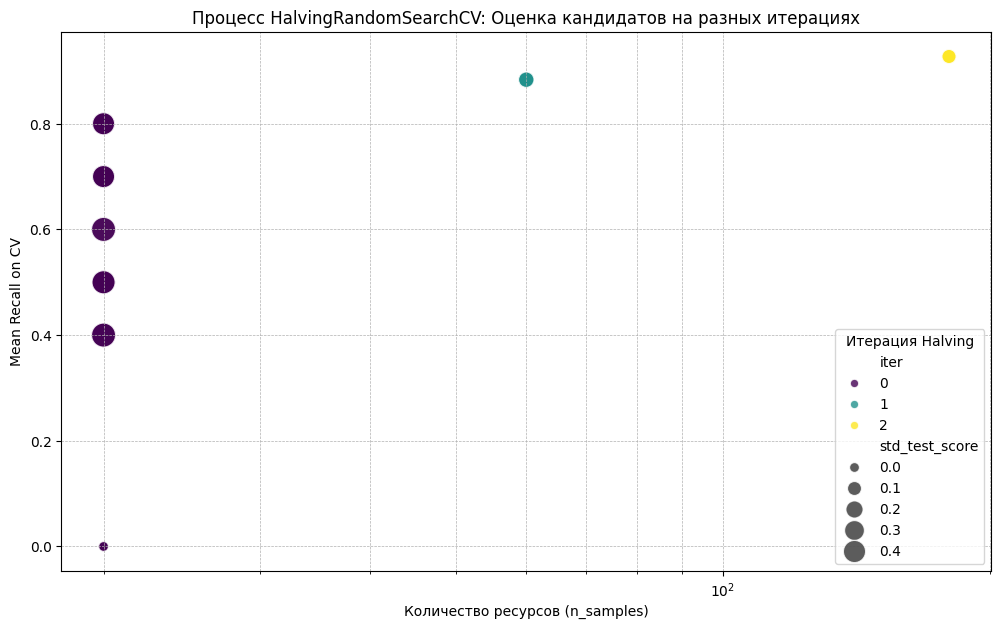

In [ ]:
# --- Визуализация процесса ---
plt.figure(figsize=(12, 7))

# Используем scatter plot, где:
scatter = sns.scatterplot(
    data=results_hrandom,
    x='n_resources',
    y='mean_test_score',
    hue='iter',
    palette='viridis', # Цветовая схема для итераций
    size='std_test_score',
    sizes=(50, 300),
    alpha=0.8
)

plt.title('Процесс HalvingRandomSearchCV: Оценка кандидатов на разных итерациях')
plt.xlabel('Количество ресурсов (n_samples)')
plt.ylabel('Mean Recall on CV')
plt.xscale('log') # Часто ресурсы растут экспоненциально, лог-шкала удобна
plt.legend(title='Итерация Halving')
plt.grid(True, which="both", ls="--", linewidth=0.5) # Сетка для лог шкалы
plt.show()


*   График показывает, как менялась оценка (`mean_test_score`) различных комбинаций гиперпараметров по мере увеличения доступных им ресурсов (`n_resources`) на разных итерациях (`iter`).
*   Точки слева соответствуют ранним итерациям с малым количеством ресурсов. Точки справа - поздним итерациям с большим количеством ресурсов.
*   Цвет точек показывает номер итерации (например, темные - ранние, светлые - поздние).
*   Мы ожидаем увидеть, что:
    *   На ранних итерациях (слева) много точек с разным качеством.
    *   На последующих итерациях (правее, цвет светлее) точек становится меньше (худшие отсеялись), и они в среднем имеют более высокое качество.
    *   Оценка качества становится более стабильной (меньший разброс, меньший размер точек `std_test_score`, если используется) на поздних итерациях с большим количеством ресурсов.
*   Этот график помогает понять, насколько агрессивно происходил отсев и как менялись оценки "выживших" кандидатов.

#### Плюсы и минусы `HalvingSearch`

**Плюсы:**
*   **Скорость:** Потенциально **значительно** быстрее, чем `GridSearchCV` и `RandomizedSearchCV`, особенно если оценка модели на полном наборе данных дорогая.
*   **Эффективность использования ресурсов:** Не тратит много времени на плохие комбинации.

**Минусы:**
*   **Риск раннего отсева:** Хорошая комбинация ГП может показать себя не очень хорошо на малом количестве данных и быть отброшенной слишком рано.
*   **Чувствительность к `factor`:** Выбор `factor` влияет на компромисс между скоростью и риском отсева. Маленький `factor` (например, 2) — меньше риск, но медленнее. Большой `factor` (например, 5) — быстрее, но выше риск.
*   **Требование к модели:** Модель должна адекватно обучаться на подвыборках данных (`resource='n_samples'`). Для некоторых моделей или задач это может быть не так.
*   **Экспериментальный статус:** API может незначительно измениться в будущих версиях `scikit-learn`.

### 7. Когда использовать Halving Search?

*   **Основной кандидат:** Когда время обучения/оценки модели на полном датасете (даже с CV) заметное (минуты и больше).
*   **Хороший старт:** `HalvingRandomSearchCV` часто является отличной отправной точкой для ОГП, так как сочетает эффективность случайного поиска с экономией ресурсов Halving.
*   **Альтернатива Grid/Random:** Если `GridSearchCV` или `RandomizedSearchCV` работают слишком долго.

## Выводы

Мы рассмотрели три основных инструмента для автоматической оптимизации гиперпараметров в scikit-learn: GridSearchCV, RandomizedSearchCV и их более эффективные аналоги HalvingGridSearchCV и HalvingRandomSearchCV.

Давайте соберем ключевые характеристики в таблицу:



| Характеристика        | `GridSearchCV`                        | `RandomizedSearchCV`                     | `HalvingGridSearchCV` / `HalvingRandomSearchCV`                       |
| :-------------------- | :------------------------------------ | :--------------------------------------- | :-------------------------------------------------------------------- |
| **Принцип работы**    | Полный перебор по сетке               | Случайный выбор `n_iter` комбинаций      | Последовательный отсев худших на растущих ресурсах (данных)         |
| **Пространство**      | Дискретная сетка (`param_grid`)       | Списки или Распределения (`param_dist`) | Сетка (`param_grid`) или Распределения (`param_dist`)                 |
| **Гарантия оптимума** | Лучший **внутри сетки**              | Нет гарантии                             | Нет гарантии (лучший из *не отсеянных*)                             |
| **Эффективность**     | Низкая (экспоненц. сложность)       | Средняя/Высокая (зависит от `n_iter`)    | **Очень высокая** (если оценка модели дорогая)                      |
| **Ключевой параметр** | Размер сетки                          | `n_iter` (число итераций)                | `factor`, `min_resources` (управляют отсевом и ресурсами)          |
| **Основной плюс**     | Простота, исчерпывающий (в сетке)     | Эффективность, гибкость пространства     | **Скорость**                                                          |
| **Основной минус**    | **Медленный**                         | Случайность, нет гарантии                | Риск раннего отсева хороших ГП, чувствительность к `factor`           |
| **Когда использовать** | Мало ГП, небольшие сетки, простота | >2-3 ГП, непрерывные ГП, контроль времени | **Оценка модели дорогая**, хочется максимальной скорости, `Random` + `Halving` - хороший старт |


## Практические Советы


*   **Начните с `HalvingRandomSearchCV`:** Это часто лучший компромисс между скоростью, качеством поиска и гибкостью задания пространства. Задайте разумное `n_iter` (или `n_candidates`) и `factor` (обычно 2 или 3).
*   **Определите пространство поиска разумно:**
    *   Используйте лог-шкалу (`loguniform` или степени двойки/десятки) для параметров, меняющихся на порядки (регуляризация, learning rate).
    *   Не делайте диапазоны слишком узкими на старте, лучше потом сузить поиск вокруг найденной хорошей области.
    *   Не включайте слишком много гиперпараметров сразу, если не уверены в их важности.

*   **Используйте адекватную CV (`cv`):** `StratifiedKFold` для классификации (особенно несбалансированной), `KFold` для регрессии. Число фолдов (splits) влияет на время: меньше фолдов - быстрее, но оценка менее надежна (обычно 3-5-10).
*   **Фиксируйте `random_state`:** Для `RandomizedSearchCV`, `HalvingRandomSearchCV` и `StratifiedKFold(shuffle=True)` используйте `random_state` для воспроизводимости результатов.
*   **Анализируйте `cv_results_` и визуализируйте:** Не смотрите только на `best_params_`. Изучение таблицы `cv_results_` и построенных графиков (зависимость метрики от параметров, тепловые карты, процесс Halving) может дать понимание, какие параметры более важны, есть ли плато или резкие пики качества, как работает сам процесс поиска.

*   **Используйте Итеративный Подход к ОГП:** Оптимизация гиперпараметров — это часто не однократный запуск, а итеративный процесс исследования:
    1.  **Этап 1: Широкий Поиск.** Начните с `RandomizedSearchCV` или `HalvingRandomSearchCV` с *широкими диапазонами* и относительно *небольшим* количеством итераций (`n_iter` или бюджетом для Halving). Цель - быстро исследовать пространство и найти общие "перспективные" области значений для каждого гиперпараметра.
        *Пример:* `max_depth: randint(3, 30)`, `min_samples_leaf: randint(2, 50)`, `n_iter=50`.
    2.  **Этап 2: Суженный Поиск.** Проанализируйте результаты первого этапа (например, с помощью визуализаций из п. 4.1). Определите более узкие диапазоны вокруг лучших найденных значений. Запустите `GridSearchCV` (если параметров 1-2 и вы хотите точно исследовать сетку) или `RandomizedSearchCV`/`HalvingRandomSearchCV` с *большим* количеством итераций (`n_iter`) в этих *суженных диапазонах*. Цель - точно настроить параметры в найденной оптимальной области.
        *Пример (если первый этап показал оптимум около `max_depth=10`, `min_samples_leaf=8`):* `max_depth: [8, 9, 10, 11, 12]`, `min_samples_leaf: [5, 6, 7, 8, 9, 10]`, `n_iter=100` (для Random) или использовать GridSearch.
    *   **Преимущества:** Такой подход позволяет эффективно использовать вычислительные ресурсы: сначала быстро находим "где искать", а потом ищем "точно" в перспективном месте. Это часто дает лучшие результаты, чем один долгий запуск с огромной сеткой или очень большим `n_iter` в широком диапазоне.

# Hyperopt (и алгоритм TPE)

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
import numpy as np

`Hyperopt` — одна из первых и наиболее известных библиотек Python для байесовской оптимизации. Она использует в качестве основного алгоритма **TPE (Tree-structured Parzen Estimators)**, который мы кратко обсуждали.

**Принцип TPE:**
*   Разделяет все предыдущие испытания (точки {ГП, результат}) на две группы: "хорошие" (например, лучшие 25% по метрике) и "плохие" (остальные).
*   Строит две вероятностные модели (оценки плотности распределения) для гиперпараметров: $l(x)$ для группы "хороших" и $g(x)$ для группы "плохих".
*   Ищет такую новую точку $x$ (комбинацию ГП), которая имеет высокую вероятность попасть в "хорошую" группу и низкую вероятность попасть в "плохую", т.е. максимизирует отношение $l(x) / g(x)$ (или похожий критерий, основанный на Expected Improvement).

**Основные шаги работы с `Hyperopt`:**

1.  **Определить пространство поиска (`space`):** Задать диапазоны и распределения для каждого гиперпараметра с помощью функций из `hyperopt.hp`.
2.  **Определить целевую функцию (`objective`):** Написать Python-функцию, которая принимает словарь параметров из `space`, выполняет оценку (например, через CV) и возвращает словарь с обязательным ключом `'loss'` (значение для минимизации).
3.  **Создать объект `Trials`:** Этот объект будет хранить всю историю поиска (параметры, результаты, время и т.д.).
4.  **Запустить оптимизацию `fmin`:** Основная функция, которая выполняет поиск, вызывая `objective` и используя алгоритм (TPE) для выбора следующих точек.

#### Пространство Поиска (`space`)

In [ ]:
# Определяем пространство поиска для Decision Tree
# Используем quniform для целочисленных параметров в диапазоне
space = {
    'max_depth': hp.quniform('max_depth', 3, 20, 1),         # Глубина от 3 до 20, шаг 1
    'min_samples_leaf': hp.quniform('min_samples_leaf', 3, 20, 1), # Листья от 3 до 20, шаг 1
    'min_samples_split': hp.quniform('min_samples_split', 5, 25, 1) # Разделение от 5 до 25, шаг 1
}

*Важно помнить:* `hp.quniform` возвращает `float`. Преобразование в `int` нужно будет делать внутри целевой функции `objective`.

#### Целевая функция (`objective`)

Эта функция связывает пространство гиперпараметров с метрикой качества.

In [ ]:
# Целевая функция для Hyperopt
# random_state для воспроизводимости внутри objective (важно для CV и модели)
objective_random_state = 42

def objective(params):
    """
    Целевая функция для минимизации Hyperopt.
    Принимает словарь гиперпараметров, возвращает словарь с 'loss' и 'status'.
    """
    # Преобразуем типы гиперпараметров из float (от quniform) в int
    params_int = {
        'max_depth': int(params['max_depth']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'min_samples_split': int(params['min_samples_split']),
    }


    # Создаем модель с текущей комбинацией гиперпараметров
    model = DecisionTreeClassifier(
        **params_int,
        random_state=objective_random_state,
        class_weight='balanced'
    )

    # Оцениваем модель с помощью кросс-валидации

    score = cross_val_score(model, X_train, y_train, cv=skf, scoring="recall", n_jobs=1).mean()
    loss = -score # !! Минимизируем отрицательный Recall (т.к. хотим максимизировать Recall) !!
    status = STATUS_OK
    metric_recall = score # Сохраним реальный recall для логов

    # Возвращаем словарь с обязательными 'loss' и 'status'
    # Добавляем доп. информацию для анализа
    return {'loss': loss, 'status': status, 'params': params_int, 'metric_recall': metric_recall}


*Ключевой момент:* `Hyperopt` всегда **минимизирует** значение ключа `'loss'`. Поэтому, если наша цель - максимизировать метрику (как `Recall`), мы должны вернуть в `'loss'` отрицательное значение этой метрики.

Проведем тест:

In [ ]:
test_params = {'max_depth': 5.0, 'min_samples_leaf': 10.0, 'min_samples_split': 15.0}
result = objective(test_params)
print(f"Тестовый вызов objective: {result}")

Тестовый вызов objective: {'loss': np.float64(-0.905241935483871), 'status': 'ok', 'params': {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 15}, 'metric_recall': np.float64(0.905241935483871)}


#### Запуск оптимизации (`fmin`)

Теперь мы готовы запустить сам процесс поиска с помощью функции `fmin`.

In [ ]:
# Создаем объект Trials для хранения истории поиска
trials = Trials()

# Устанавливаем бюджет поиска - количество оценок целевой функции
max_evals = 50 # Попробуем 50 комбинаций гиперпараметров

# Задаем генератор случайных чисел для воспроизводимости TPE
fmin_rstate = np.random.default_rng(42)

print(f"\nЗапуск Hyperopt fmin (алгоритм TPE) на {max_evals} итераций...")
start_time_hyperopt = time.time()

# Запускаем fmin
best = fmin(
    fn=objective,            # Наша целевая функция
    space=space,             # Определенное нами пространство поиска
    algo=tpe.suggest,        # Алгоритм оптимизации (TPE)
    max_evals=max_evals,     # Максимальное число вызовов objective
    trials=trials,           # Объект для сохранения истории
    rstate=fmin_rstate,      # Состояние генератора случайных чисел для TPE
    show_progressbar=True    # Установим True, если хотим видеть прогресс-бар
)
end_time_hyperopt = time.time()
hyperopt_time = end_time_hyperopt - start_time_hyperopt
print(f"Hyperopt fmin завершен за {hyperopt_time:.2f} секунд.")



Запуск Hyperopt fmin (алгоритм TPE) на 50 итераций...
100%|██████████| 50/50 [00:04<00:00, 12.34trial/s, best loss: -0.9308467741935484]
Hyperopt fmin завершен за 4.06 секунд.


In [ ]:
# --- Анализ результата ---

# `fmin` возвращает словарь, где значения соответствуют ЛУЧШИМ вариантам из `space`.
# Внимание: для `hp.choice` возвращается ИНДЕКС лучшего варианта!
print("\nСырой результат 'best', возвращенный fmin:")
print(best)

# Чтобы получить читаемый словарь с лучшими параметрами (с реальными значениями),
# нужно использовать функцию `space_eval`.
best_params_hyperopt = space_eval(space, best)
print("\nЛучшие параметры, найденные Hyperopt (обработанные space_eval):")
print(best_params_hyperopt)

# Найдем лучший результат (минимальное значение loss) непосредственно из объекта trials.
# Это надежнее, чем просто смотреть на `best`, т.к. trials хранит всю историю.
best_trial_info = trials.best_trial
best_loss = best_trial_info['result']['loss']
best_recall_hyperopt = -best_loss # Так как loss = -recall

print(f"\nИнформация о лучшем испытании из trials:")
print(f"  Итерация (TID): {best_trial_info['tid']}")
print(f"  Loss (минимизирован): {best_loss:.4f}")
print(f"  Recall (максимизирован): {best_recall_hyperopt:.4f}")
print(f"  Параметры этого испытания: {best_trial_info['result']['params']}")


Сырой результат 'best', возвращенный fmin:
{'max_depth': np.float64(12.0), 'min_samples_leaf': np.float64(4.0), 'min_samples_split': np.float64(13.0)}

Лучшие параметры, найденные Hyperopt (обработанные space_eval):
{'max_depth': 12.0, 'min_samples_leaf': 4.0, 'min_samples_split': 13.0}

Информация о лучшем испытании из trials:
  Итерация (TID): 27
  Loss (минимизирован): -0.9308
  Recall (максимизирован): 0.9308
  Параметры этого испытания: {'max_depth': 12, 'min_samples_leaf': 4, 'min_samples_split': 13}


In [ ]:
from sklearn.metrics import recall_score

# Применяем int() к параметрам, которые должны быть целочисленными
best_params_hyperopt['max_depth'] = best_trial_info['result']['params']['max_depth']
best_params_hyperopt['min_samples_leaf'] = best_trial_info['result']['params']['min_samples_leaf']
best_params_hyperopt['min_samples_split'] = best_trial_info['result']['params']['min_samples_split']


# Теперь у нас есть лучшие параметры, и мы можем обучить финальную модель
print("\nОбучение финальной модели с лучшими параметрами Hyperopt...")
final_model_hyperopt = DecisionTreeClassifier(
    **best_params_hyperopt,
    random_state=objective_random_state,
    class_weight='balanced'
)
final_model_hyperopt.fit(X_train, y_train)
print("Финальная модель обучена.")




Обучение финальной модели с лучшими параметрами Hyperopt...
Финальная модель обучена.


In [ ]:
# Оценка на тесте
y_test_pred_hyperopt = final_model_hyperopt.predict(X_test)
recall_test_hyperopt = recall_score(y_test, y_test_pred_hyperopt)
print(f"\nОценка финальной модели Hyperopt на ТЕСТОВОЙ выборке:")
print(f"  Recall: {recall_test_hyperopt:.4f}")


Оценка финальной модели Hyperopt на ТЕСТОВОЙ выборке:
  Recall: 0.8679


## Когда использовать байесовскую оптимизацию?

Байесовская Оптимизация наиболее эффективна в следующих сценариях:

1.  **Дорогая оценка целевой функции:** Когда один вызов `objective` (обучение модели + кросс-валидация) занимает значительное время (от десятков секунд до минут и часов). БО позволяет найти хорошие решения за меньшее *количество вызовов* `objective` по сравнению с Grid/Random/Halving Search.
2.  **Сложное пространство поиска:** Когда у вас много гиперпараметров (например, > 5-10), есть непрерывные параметры, или вы подозреваете сложные взаимодействия между ними. БО способна эффективнее исследовать такие пространства.
3.  **Ограниченный бюджет оценок:** Если у вас есть лимит на количество комбинаций, которые вы можете проверить (например, из-за временных или вычислительных ограничений), БО часто дает лучший результат за то же число итераций, чем Random Search.
4.  **Нужны условные параметры:** Если структура вашей модели такова, что одни гиперпараметры имеют смысл только при определенных значениях других.

**Когда БО может быть излишней?**

*   **Очень быстрая оценка `objective`:** Если обучение и оценка модели занимают доли секунды, то накладные расходы на БО (обновление суррогатной модели, поиск по функции приобретения) могут стать сопоставимы или даже больше времени оценки `objective`. В таких случаях `HalvingRandomSearchCV` может оказаться быстрее и проще.
*   **Очень мало гиперпараметров (1-2):** Проще и надежнее может быть использовать `GridSearchCV` с мелкой сеткой или `RandomizedSearchCV` с большим `n_iter`.




## Итоговые рекомендации

Мы рассмотрели целый спектр инструментов для оптимизации гиперпараметров, от простых до продвинутых:

1.  **`GridSearchCV`:** Просто, исчерпывающе (в сетке), но медленно. Подходит для 1-2 параметров с небольшим числом значений.
2.  **`RandomizedSearchCV`:** Эффективнее GridSearch, гибкое пространство. Хороший базовый вариант.
3.  **`Halving[...]SearchCV`:** Значительно ускоряет Grid/Random Search за счет раннего отсева. Отличный выбор, если оценка модели дорогая и модель хорошо учится на подвыборках. **`HalvingRandomSearchCV` - часто лучший первый шаг.**
4.  **Байесовская Оптимизация (`Hyperopt`, `Optuna`):** "Умный" поиск, эффективный по числу оценок. Идеально, когда оценка `objective` очень дорогая или пространство поиска сложное.
    *   **`Hyperopt`:** Базовый TPE.
    *   **`Optuna`:** Современный, гибкий выбор с TPE/другими Sampler'ами, встроенными Pruning и Визуализацией, легкой поддержкой условных ГП. **Рекомендуется для большинства задач, требующих БО.**

**Общие Рекомендации:**

*   **Начните с простого:** Если не уверены, попробуйте `HalvingRandomSearchCV`.
*   **Если оценка дорогая:** Переходите к БО (`Optuna` предпочтительнее). Используйте Pruning в `Optuna`.
*   **Тщательно определяйте пространство поиска:** Используйте лог-шкалу, не делайте диапазоны слишком узкими вначале.
*   **Выберите правильную метрику и CV.**
*   **Отслеживайте эксперименты:** Используйте `MLflow` или аналоги.
*   **Оценивайте финальную модель на отложенном тесте.**
*   **Помните, ОГП - итеративный процесс:** Анализируйте результаты, корректируйте пространство, повторяйте.


